In [324]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [325]:
df = pd.read_csv("../data/netflix.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [326]:
print("Shape of dataset:", df.shape)
df.info()

Shape of dataset: (8807, 12)
<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 825.8 KB


In [327]:
df.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [328]:
# Fill categorical missing values
df['director'].fillna('Unknown', inplace=True)
df['cast'].fillna('Unknown', inplace=True)
df['country'].fillna('Unknown', inplace=True)
df['rating'].fillna('Not Rated', inplace=True)

# Drop rows with missing date_added
df = df.dropna(subset=['date_added'])

# Remove extra spaces
df['date_added'] = df['date_added'].str.strip()

# Convert to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Create new feature
df['year_added'] = df['date_added'].dt.year

C:\Users\anike\AppData\Local\Temp\ipykernel_19392\516860029.py:2: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment using an inplace method.
Such inplace method never works to update the original DataFrame or Series, because the intermediate object on which we are setting values always behaves as a copy (due to Copy-on-Write).

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' instead, to perform the operation inplace on the original object, or try to avoid an inplace operation using 'df[col] = df[col].method(value)'.

See the documentation for a more detailed explanation: https://pandas.pydata.org/pandas-docs/stable/user_guide/copy_on_write.html
  df['director'].fillna('Unknown', inplace=True)
C:\Users\anike\AppData\Local\Temp\ipykernel_19392\516860029.py:3: ChainedAssignmentError: A value is being set on a copy of a DataFrame or Series through chained assignment usi

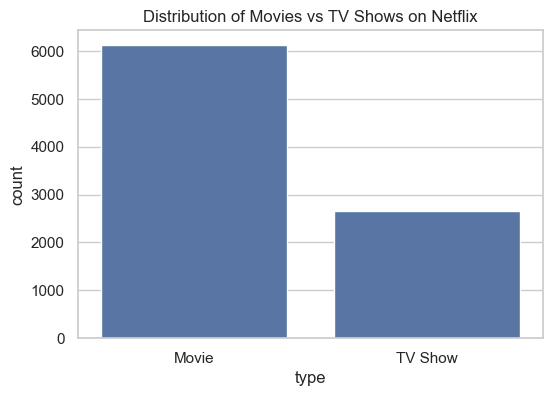

In [329]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='type')
plt.title("Distribution of Movies vs TV Shows on Netflix")

plt.savefig("../images/movies_vs_tv.png")
plt.show()

## Insight 1: Movies vs TV Shows Distribution

- Netflix has significantly more Movies (~6000) than TV Shows (~2500).
- Movies make up more than 70% of the platform’s content.
- This suggests Netflix prioritizes movie content over TV series.

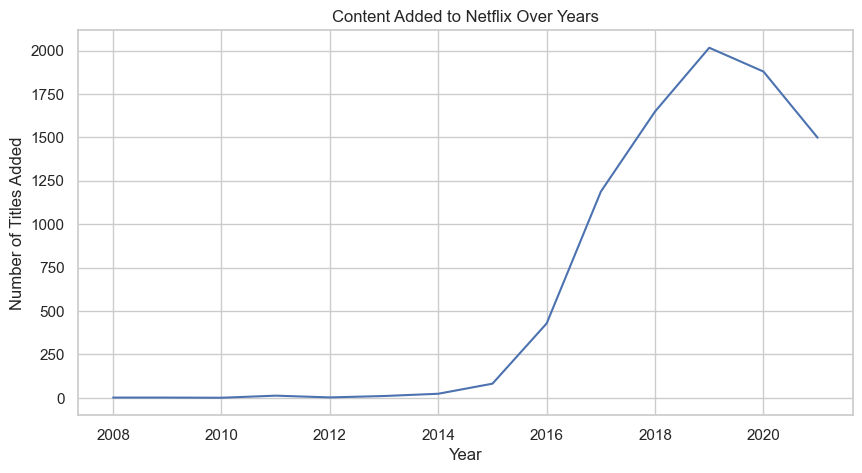

In [330]:
plt.figure(figsize=(10,5))
df['year_added'].value_counts().sort_index().plot(kind='line')
plt.title("Content Added to Netflix Over Years")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")

plt.savefig("../images/content_growth.png")
plt.show()

## Insight 2: Content Growth Over Years

- Netflix saw exponential growth between 2016 and 2019.
- Peak content addition occurred around 2019 (~2000 titles).
- Slight decline observed after 2019, possibly due to production slowdowns or strategic shifts.
- The major expansion phase indicates aggressive global scaling.

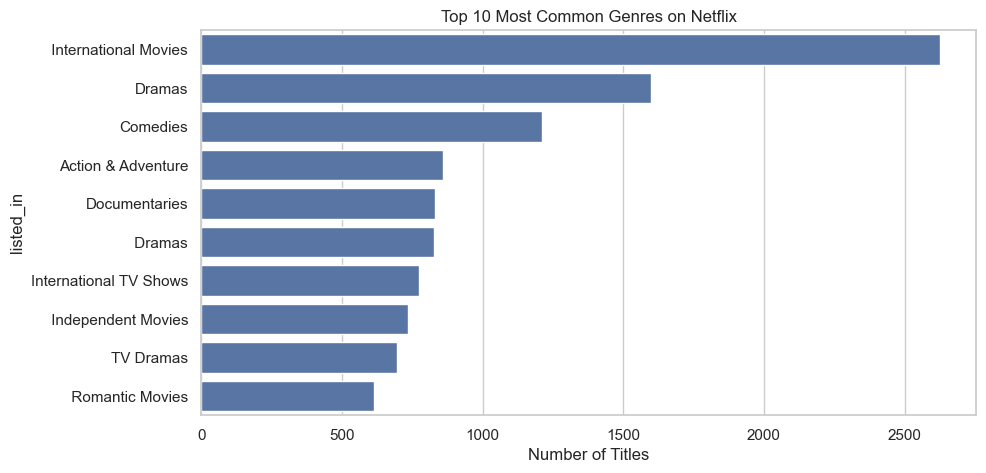

In [331]:
top_genres = df['listed_in'].str.split(',').explode().value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Most Common Genres on Netflix")
plt.xlabel("Number of Titles")

plt.savefig("../images/top_genres.png")
plt.show()

## Insight 3: Genre Distribution

- International Movies are the most common content category.
- Drama and Comedy follow closely, indicating strong audience demand.
- Netflix appears to focus heavily on global and diverse content.
- The platform offers high genre diversity.

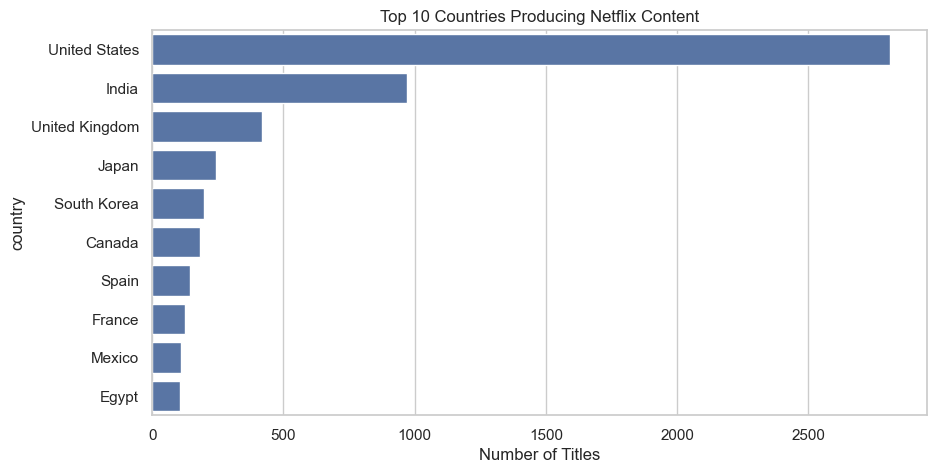

In [332]:
top_countries = df['country'].value_counts().head(10)

plt.figure(figsize=(10,5))
sns.barplot(x=top_countries.values, y=top_countries.index)
plt.title("Top 10 Countries Producing Netflix Content")
plt.xlabel("Number of Titles")

plt.savefig("../images/top_countries.png")
plt.show()

## Insight 4: Country Distribution

- The United States produces the highest number of titles.
- India is the second-largest contributor.
- Netflix has strong content production across Asia (India, Japan, South Korea).
- This reflects Netflix’s global expansion strategy.